In [20]:
import torch
import numpy as np

import matplotlib.pyplot as plt
%matplotlib inline

In [21]:
import torch
import torch.nn as nn
import torch.nn.functional as F


class BayesianFlowNetwork(nn.Module):
    """
    Bayesian Flow Network (BFN) cho dữ liệu rời rạc.

    Ý tưởng chính:
    - θ là tham số của input distribution p_I(x | θ)
      (một categorical distribution cho từng chiều dữ liệu).
    - Network nhận (θ, t) và dự đoán output distribution p_O.
    - Training sử dụng continuous-time loss L∞ trong paper.
    """

    def __init__(self, D=2, K=2, hidden_dim=32, beta=3.0):
        super(BayesianFlowNetwork, self).__init__()

        # β(1) trong paper
        self.beta = beta

        # số chiều dữ liệu
        self.D = D

        # số class của mỗi chiều
        self.K = K

        # Với K=2 chỉ cần dự đoán 1 logit
        # class còn lại được suy ra bằng 1-p
        output_classes = K if K > 2 else 1

        # Network Ψ(θ,t)
        #
        # Input:
        #   θ ∈ [0,1]^(D×K)
        #   t ∈ [0,1]
        #
        # Output:
        #   logits của p_O
        self.layer = nn.Sequential(
            nn.Linear(D * K + 1, hidden_dim),
            nn.GELU(),
            nn.Linear(hidden_dim, D * output_classes)
        )

    def forward(self, theta, t):
        """
        Tính Ψ(θ,t).

        Parameters
        ----------
        theta : (B, D, K)
            Input distribution của BFN.

        t : (B,)
            Thời gian liên tục.

        Returns
        -------
        output : logits của output distribution.
        """

        # Softmax tạo θ trong [0,1]
        # Scale về [-1,1] giúp network học ổn định hơn
        theta = (theta * 2) - 1

        # Flatten toàn bộ simplex D×K
        theta = theta.view(theta.shape[0], -1)

        # Ghép thêm time t
        input_ = torch.cat((theta, t.unsqueeze(-1)), dim=-1)

        # Ψ(θ,t)
        output = self.layer(input_)

        # reshape về (B,D,*)
        output = output.view(output.shape[0], self.D, -1)

        return output

    def discrete_output_distribution(self, theta, t):
        """
        Hiện thực Algorithm:
            discrete output distribution(θ,t)

        Trả về p_O(k | θ,t).

        Trong paper:

            p_O = softmax(Ψ(θ,t))

        riêng K=2 dùng sigmoid.
        """

        B, D, K = theta.shape

        # Ψ(θ,t)
        output = self.forward(theta, t)

        if K == 2:
            # Binary categorical
            p0_1 = torch.sigmoid(output)

            # xác suất class còn lại
            p0_2 = 1 - p0_1

            p0 = torch.cat((p0_1, p0_2), dim=-1)

        else:
            # Eq. (126)
            p0 = F.softmax(output, dim=-1)

        return p0

    def process(self, x):
        """
        Training step theo Algorithm 8:
            Continuous-Time Loss L∞(x)
            for Discrete Data
        """

        B, D = x.shape

        # --------------------------------------------------
        # Step 1
        # t ~ Uniform(0,1)
        # --------------------------------------------------
        t = torch.rand(
            (x.size(0),),
            device=x.device,
            dtype=torch.float32
        )

        # --------------------------------------------------
        # Step 2
        # β = β(1) * t²
        # --------------------------------------------------
        beta = self.beta * (t ** 2)

        # --------------------------------------------------
        # Step 3
        # Sinh noisy message:
        #
        # y ~ N(
        #       β(K e_x - 1),
        #       βK I
        #      )
        #
        # đúng theo Algorithm 8
        # --------------------------------------------------
        one_hot_x = F.one_hot(
            x,
            num_classes=self.K
        ).float()

        mean = beta[:, None, None] * (
            self.K * one_hot_x - 1
        )

        std = (beta * self.K)[:, None, None].sqrt()

        eps = torch.randn_like(mean)

        y = mean + std * eps

        # --------------------------------------------------
        # Step 4
        # θ = softmax(y)
        #
        # Đây là input distribution p_I
        # sau khi nhận thông tin từ sender.
        # --------------------------------------------------
        theta = F.softmax(y, dim=-1)

        # --------------------------------------------------
        # Step 5
        # p_O(. | θ,t)
        # --------------------------------------------------
        p_0 = self.discrete_output_distribution(
            theta,
            t
        )

        # e_x trong paper
        e_x = one_hot_x

        # ê(θ,t)
        #
        # với dữ liệu rời rạc:
        # ê = E[e_k]
        #
        # thực tế chính là vector xác suất p_O
        e_hat = p_0

        # --------------------------------------------------
        # Continuous-time loss:
        #
        # L∞ = K β(1) t ||e_x - ê||²
        #
        # Algorithm 8
        # --------------------------------------------------
        L_infinity = (
            self.K
            * self.beta
            * t[:, None, None]
            * ((e_x - e_hat) ** 2)
        )

        return L_infinity.mean()

    @torch.inference_mode()
    def sample(
        self,
        batch_size=128,
        nb_steps=10,
        device='cpu'
    ):
        """
        Sampling theo Algorithm 9.

        Bắt đầu từ prior đồng đều:
            θ = 1/K

        Sau đó lặp:
            θ -> p_O -> k
            k -> y
            y -> Bayesian update của θ
        """

        self.eval()

        # --------------------------------------------------
        # Prior:
        #
        # θ₀ = 1/K
        #
        # Eq. (125)
        # --------------------------------------------------
        theta = (
            torch.ones(
                (batch_size, self.D, self.K),
                device=device
            ) / self.K
        )

        for i in range(1, nb_steps + 1):

            # t = (i-1)/n
            t = (i - 1) / nb_steps

            t = t * torch.ones(
                (theta.shape[0]),
                device=theta.device,
                dtype=theta.dtype
            )

            # --------------------------------------------------
            # Sample:
            # k ~ p_O(.|θ,t)
            # --------------------------------------------------
            k_probs = self.discrete_output_distribution(
                theta,
                t
            )

            k = torch.distributions.Categorical(
                probs=k_probs
            ).sample()

            # --------------------------------------------------
            # α_i
            #
            # Algorithm 9:
            #
            # α = β(1)(2i-1)/n²
            # --------------------------------------------------
            alpha = (
                self.beta
                * (2 * i - 1)
                / (nb_steps ** 2)
            )

            e_k = F.one_hot(
                k,
                num_classes=self.K
            ).float()

            # y ~ N(
            #        α(K e_k - 1),
            #        αK I
            #      )
            mean = alpha * (
                self.K * e_k - 1
            )

            var = alpha * self.K

            std = torch.full_like(
                mean,
                fill_value=var
            ).sqrt()

            eps = torch.randn_like(e_k)

            y = mean + std * eps

            # --------------------------------------------------
            # Bayesian update:
            #
            # θ' = exp(y) * θ
            # θ  = normalize(θ')
            #
            # chính là update posterior
            # của input distribution.
            # --------------------------------------------------
            theta_prime = torch.exp(y) * theta

            theta = (
                theta_prime
                / theta_prime.sum(
                    -1,
                    keepdim=True
                )
            )

        # --------------------------------------------------
        # Final sample tại t=1
        # --------------------------------------------------
        k_probs_final = (
            self.discrete_output_distribution(
                theta,
                torch.ones_like(t)
            )
        )

        k_final = torch.distributions.Categorical(
            probs=k_probs_final
        ).sample()

        return k_final

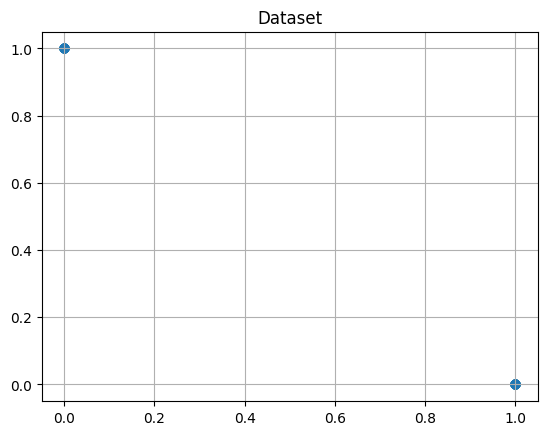

In [22]:
# Dataset toy:
#
# x0 và x1 luôn đối nghịch nhau
#
# (0,1)
# (1,0)
#
# Network phải học được phân phối:
#
# P(x1=1 | x0=0)=1
# P(x1=0 | x0=1)=1
#
# Đây là bài toán kiểm tra xem BFN có học được
# dependency giữa các chiều dữ liệu hay không.
def get_datapoint(batch=128, device='cpu'):

    # x0 ~ Bernoulli(0.5)
    x0 = torch.randint(
        0,
        2,
        size=(batch,),
        dtype=torch.bool,
        device=device
    )

    # x1 = NOT x0
    x1 = ~x0

    # Ghép thành vector dữ liệu:
    #
    # [0,1]
    # hoặc
    # [1,0]
    X = torch.stack([x0, x1], dim=0)

    # Shape:
    # (batch, D=2)
    return X.long().transpose(0, 1)


# Sinh một batch mẫu
X = get_datapoint()

# Visualize dataset
#
# Chỉ xuất hiện 2 cụm:
#
# (0,1)
# (1,0)
plt.title("Dataset")
plt.scatter(X[:, 0], X[:, 1])
plt.grid()

  0%|          | 0/10000 [00:00<?, ?it/s]

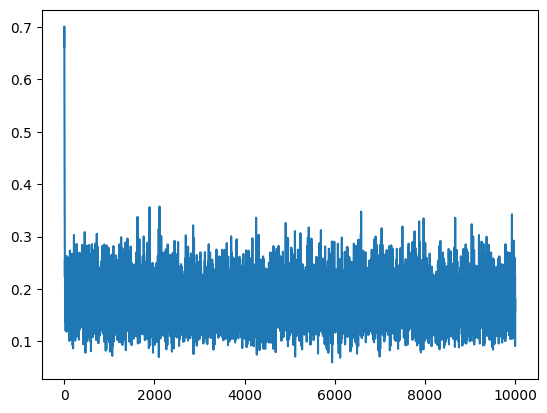

In [23]:
import torch
from torch.optim import AdamW
from tqdm.auto import tqdm

# Tạo Bayesian Flow Network
bfn = BayesianFlowNetwork()

# Đưa model lên GPU
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
bfn.to(device)

# Optimizer
optim = AdamW(
    bfn.parameters(),
    lr=1e-2
)

n = 10000 # 100, 1000, 5000, 10000, 50000
losses = []
for i in tqdm(range(n)):
    optim.zero_grad()
    # Sinh batch mới
    X = get_datapoint(device=device)
    # Tính continuous-time loss L∞
    loss = bfn.process(X)
    # Backprop
    loss.backward()
    # Cập nhật tham số Ψ
    optim.step()
    losses.append(loss.item())
plt.plot(losses)

In [24]:
# ==========================================================
# Sampling từ Bayesian Flow Network đã train xong
# ==========================================================

with torch.inference_mode():

    # Sinh 5000 mẫu bằng Algorithm 9 trong paper
    #
    # Bắt đầu từ prior:
    #     θ = [0.5, 0.5]
    #
    # Sau đó lặp 100 bước:
    #     θ -> p_O -> k
    #     k -> Gaussian message
    #     message -> Bayesian update
    #
    # Cuối cùng sample categorical tại t=1
    x_hat = bfn.sample(
        batch_size=5000,
        device=device,
        nb_steps=100
    )

# Chuyển sang numpy để visualize
x_hat = x_hat.cpu().numpy()

# ----------------------------------------------------------
# Kiểm tra định lượng phân phối đã học
#
# Nếu model học tốt:
#
#     [0,1] ≈ 50%
#     [1,0] ≈ 50%
#
# Và gần như không xuất hiện:
#
#     [0,0]
#     [1,1]
# ----------------------------------------------------------
unique, counts = np.unique(
    x_hat,
    axis=0,
    return_counts=True
)

print("Generated distribution:")
for u, c in zip(unique, counts):
    print(
        f"{u} -> {c} samples "
        f"({100*c/len(x_hat):.2f}%)"
    )

Generated distribution:
[0 0] -> 61 samples (1.22%)
[0 1] -> 2356 samples (47.12%)
[1 0] -> 2519 samples (50.38%)
[1 1] -> 64 samples (1.28%)


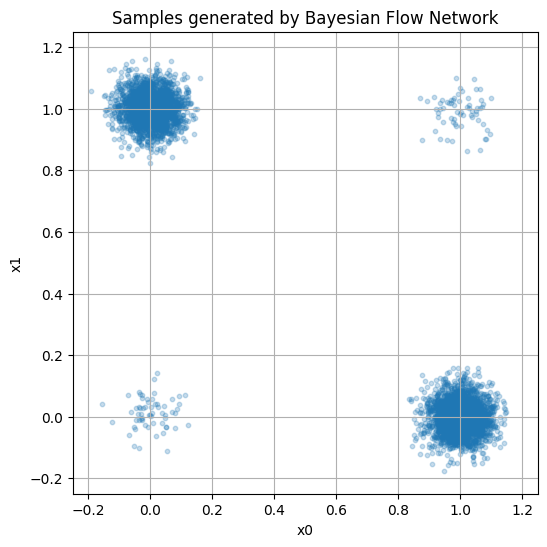

In [25]:
# ==========================================================
# Visualize các sample sinh ra từ BFN
# ==========================================================

# Scatter plot sẽ bị chồng điểm vì dữ liệu chỉ gồm:
#
#     (0,1)
#     (1,0)
#
# nên thêm jitter nhỏ để nhìn rõ mật độ

x_vis = x_hat.astype(np.float32)

x_vis += np.random.normal(
    loc=0.0,
    scale=0.05,
    size=x_vis.shape
)

plt.figure(figsize=(6, 6))

plt.scatter(
    x_vis[:, 0],
    x_vis[:, 1],
    alpha=0.25,
    s=10
)

# Giới hạn trục để nhìn rõ hai mode
plt.xlim(-0.25, 1.25)
plt.ylim(-0.25, 1.25)

plt.xlabel("x0")
plt.ylabel("x1")

plt.title(
    "Samples generated by Bayesian Flow Network"
)

plt.grid(True)

plt.show()